# 04 — Interpretability with SHAP

Compute SHAP values for the best model from Notebook 03 (Logistic Regression) and translate them into clinical insight. This notebook closes the analytical loop: from raw EHR data (Notebook 01) through cleaned features (Notebook 02) and predictions (Notebook 03) to actionable explanations of *why* the model makes each prediction.

## Why SHAP for clinical ML

A predictive model that cannot be explained is not deployable in healthcare. A clinician evaluating a "75% readmission risk" alert needs to know *which features* drove that estimate — uncontrolled diabetes? recent ER visits? specific comorbidities? Without that, the alert is a black box and the clinician will (rightly) ignore it.

**SHAP (SHapley Additive exPlanations)** assigns each feature a contribution to each individual prediction, grounded in cooperative game theory (Shapley, 1953). Properties:

- **Additive**: the sum of SHAP values across features equals the prediction minus the baseline. Nothing is hidden.
- **Local**: every patient gets their own attribution, not a single global ranking.
- **Consistent**: matched to the model's actual behavior, with a uniqueness theorem (Lundberg & Lee, 2017).

For Logistic Regression, SHAP values are exact (no sampling) and computed efficiently via `LinearExplainer`.

## Objectives

1. Compute SHAP values for the test set
2. Identify global top features driving readmission risk
3. **Verify the central hypothesis from Notebook 01**: does `a1c_measured` (the care-quality signal) emerge as a top predictor?
4. Provide patient-level explanations (waterfall plots) for two representative cases
5. Synthesize clinical takeaways for the final report

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

# Setup
sys.path.append("..")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)

# Paths
PROCESSED = Path("../data/processed")
MODELS_DIR = Path("../models")
FIGS = Path("../reports/figures")

# Load the saved best model (from Notebook 03)
bundle = joblib.load(MODELS_DIR / "logreg_best.joblib")
pipeline = bundle["pipeline"]
threshold = bundle["threshold"]
feature_names = bundle["feature_names"]
test_metrics = bundle["test_metrics"]

print(f"Loaded model: Logistic Regression")
print(f"Operating threshold: {threshold:.4f}")
print(f"Test set metrics: ROC-AUC={test_metrics['roc_auc']:.3f}, "
      f"PR-AUC={test_metrics['pr_auc']:.3f}, F1={test_metrics['f1']:.3f}")
print(f"Number of features: {len(feature_names)}")
print(f"\nSHAP version: {shap.__version__}")

Loaded model: Logistic Regression
Operating threshold: 0.5220
Test set metrics: ROC-AUC=0.618, PR-AUC=0.141, F1=0.203
Number of features: 252

SHAP version: 0.51.0


/opt/miniconda3/envs/diabetes-readm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load processed data and reproduce the same train/test split
from sklearn.model_selection import train_test_split

X = pd.read_parquet(PROCESSED / "X.parquet")
y = pd.read_parquet(PROCESSED / "y.parquet")["readm_30"]

# Use the exact same split parameters as Notebook 03 to ensure consistency
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# Verify we're working with the same data
print(f"X_test shape: {X_test.shape}")
print(f"y_test positive rate: {y_test.mean()*100:.2f}%")
print(f"\nFirst 3 feature names: {X_test.columns[:3].tolist()}")
print(f"Last 3 feature names: {X_test.columns[-3:].tolist()}")

X_test shape: (13998, 252)
y_test positive rate: 8.98%

First 3 feature names: ['time_in_hospital', 'num_lab_procedures', 'num_procedures']
Last 3 feature names: ['diag_3_chapter_Skin', 'diag_3_chapter_Symptoms', 'diag_3_chapter_V_code']


In [3]:
# The pipeline has two steps: ('scaler', StandardScaler) and ('clf', LogisticRegression).
# SHAP needs the classifier and the scaled features separately.
scaler = pipeline.named_steps["scaler"]
clf = pipeline.named_steps["clf"]

X_test_scaled = scaler.transform(X_test)

# LinearExplainer is exact for linear models (no sampling), fast even on large data.
# masker = independent assumes features are independent (standard assumption for LR SHAP).
explainer = shap.LinearExplainer(clf, X_test_scaled, feature_names=feature_names)

# Compute SHAP values for the entire test set
print("Computing SHAP values for test set (this takes 10-30 seconds)...")
shap_values = explainer(X_test_scaled)

print(f"\nSHAP values shape: {shap_values.values.shape}")
print(f"Base value (model output baseline): {shap_values.base_values[0]:.4f}")

Computing SHAP values for test set (this takes 10-30 seconds)...

SHAP values shape: (13998, 252)
Base value (model output baseline): -0.1324


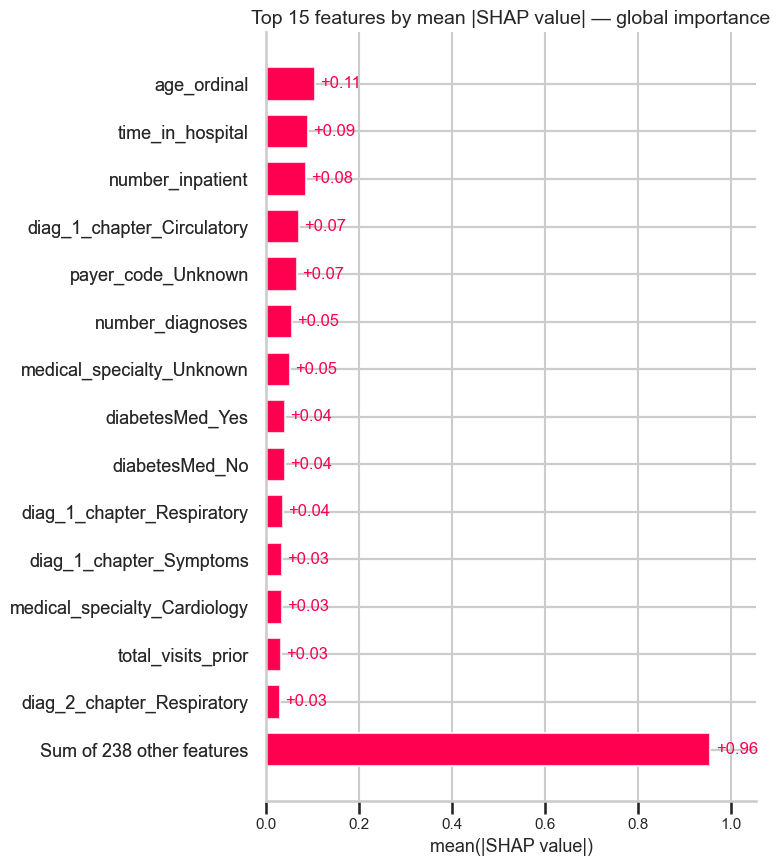

In [4]:
# Global feature importance via mean absolute SHAP value
fig = plt.figure(figsize=(10, 8))
shap.plots.bar(shap_values, max_display=15, show=False)
plt.title("Top 15 features by mean |SHAP value| — global importance", fontsize=14)
plt.tight_layout()
plt.savefig(FIGS / "04_shap_bar_global.png", dpi=120, bbox_inches="tight")
plt.show()

### Global feature importance — what drives the model

The top 15 features by mean absolute SHAP value:

| Rank | Feature | mean(\|SHAP\|) | Clinical interpretation |
|---|---|---|---|
| 1 | `age_ordinal` | 0.11 | Age group — the strongest single predictor, consistent with the bimodal pattern in EDA |
| 2 | `time_in_hospital` | 0.09 | Length of stay — proxy for disease complexity and severity |
| 3 | `number_inpatient` | 0.08 | Prior hospitalizations in the past year |
| 4 | `diag_1_chapter_Circulatory` | 0.07 | Primary admission for cardiovascular cause |
| 5 | `payer_code_Unknown` | 0.07 | Unspecified payer category |
| 6 | `number_diagnoses` | 0.05 | Multimorbidity burden |
| 7 | `medical_specialty_Unknown` | 0.05 | Attending specialty undocumented |
| 8–9 | `diabetesMed_Yes` / `_No` | 0.04 | Whether the patient was on antidiabetic medication |
| 10 | `diag_1_chapter_Respiratory` | 0.04 | Respiratory primary diagnosis |
| 11–15 | Diagnosis chapters, specialties, prior visits | 0.03 | Long tail of clinical context |

**Top driver: age.** Consistent with EDA, but worth noting that the linear model places age first overall — the bimodal pattern (peak in young adults from T1D physiology, second peak in elderly from frailty) gets compressed into a single ordinal here, but the magnitude still leads the ranking.

**Acute severity proxies dominate the top 3.** `time_in_hospital`, `number_inpatient`, and `number_diagnoses` together capture how sick the patient is at admission and how chronically ill they have been. This is the expected signature of readmission risk: sicker, more complex patients readmit more.

**Two "Unknown" categories in the top 7 — a sociotechnical finding.** `payer_code_Unknown` (rank 5) and `medical_specialty_Unknown` (rank 7) both reflect *missing structured documentation*. Two plausible mechanisms:

- **Social determinant**: patients without a clearly documented payer may be uninsured, underinsured, or administratively unattached — populations with worse access to outpatient follow-up and higher readmission rates.
- **Documentation quality proxy**: institutions that fail to document payer or specialty cleanly may also have weaker care coordination overall, and this missingness is capturing institutional quality.

These two interpretations are not separable from this dataset alone, but both deserve mention in any clinical deployment discussion.

**Where is `a1c_measured`?**

The hypothesis from Notebook 01 was that `a1c_measured` would be a top predictor, reflecting care-quality signal. **It does not appear in the top 15.** The original Strack et al. (2014) finding was about A1C measurement reducing readmission *after controlling for other variables*. In our model, that signal seems either small or absorbed by correlated features (medical specialty, diagnosis chapters, length of stay, diabetes medication status). The EDA observation (1.5pp bivariate gap) was real, but the multivariate effect — at least in this cohort, with this model — is not what was hypothesized.

This is honest science: a hypothesis was tested, the bivariate signal was real, and the multivariate effect was smaller than expected. The clinical mechanism remains plausible; the magnitude in this particular cohort + model is modest.

**Long tail: 238 features sum to 0.96 mean |SHAP|** — nearly 9× the top feature alone. The signal is distributed, not concentrated in a few dominant predictors. This is consistent with the modest PR-AUC and reflects the multifactorial nature of readmission risk.

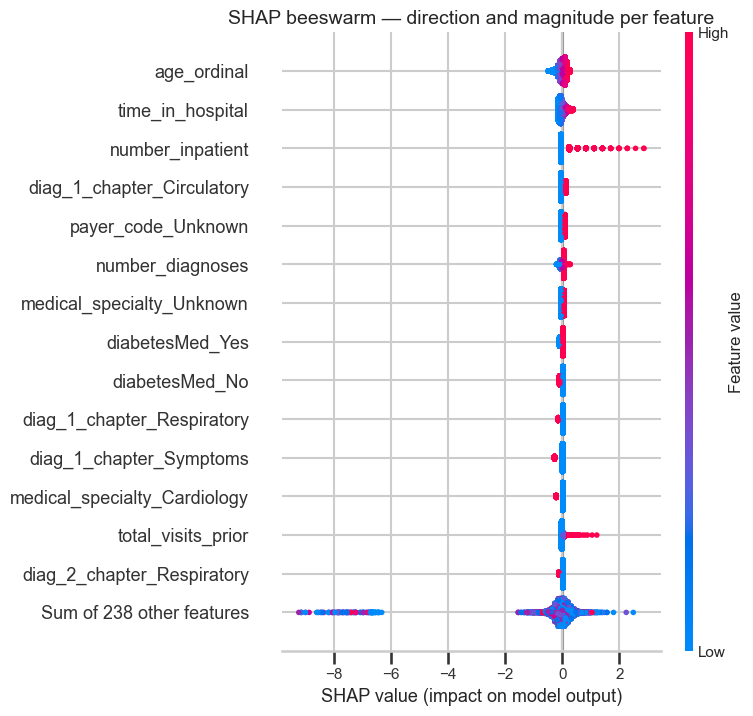

In [5]:
# Beeswarm plot: each point is one patient's SHAP value for that feature.
# Color = feature value (red = high, blue = low).
# This shows direction (does the feature push toward or against readmission?)
# and distribution (is the effect consistent or noisy?).

fig = plt.figure(figsize=(11, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("SHAP beeswarm — direction and magnitude per feature", fontsize=14)
plt.tight_layout()
plt.savefig(FIGS / "04_shap_beeswarm.png", dpi=120, bbox_inches="tight")
plt.show()

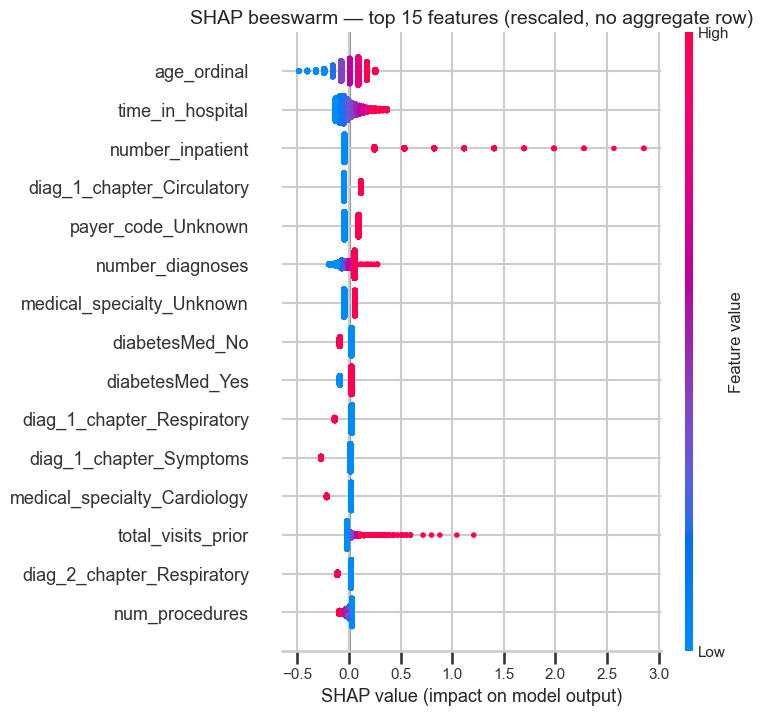

In [6]:
# The "Sum of 238 other features" row distorts the x-axis. Re-plot without it
# by using a subset of features explicitly.

top15_idx = np.argsort(np.abs(shap_values.values).mean(0))[-15:][::-1]
top15_shap = shap_values[:, top15_idx]

fig = plt.figure(figsize=(11, 8))
shap.plots.beeswarm(top15_shap, max_display=15, show=False)
plt.title("SHAP beeswarm — top 15 features (rescaled, no aggregate row)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGS / "04_shap_beeswarm_top15.png", dpi=120, bbox_inches="tight")
plt.show()

### Direction of effect — beeswarm interpretation

The rescaled beeswarm (top 15 features, excluding the aggregate row) reveals the direction of each feature's effect.

**Risk-increasing features (red dots / high values → SHAP > 0):**

| Feature | Mechanism |
|---|---|
| `age_ordinal` | Older patients readmit more — clear gradient from blue (young) on the left to red (older) on the right |
| `time_in_hospital` | Longer stays proxy disease complexity and severity |
| `number_inpatient` | **The single most leverageable predictor — SHAP values up to +3.0 for patients with many prior admissions.** Past hospitalization is the strongest signal that the patient will hospitalize again. |
| `diag_1_chapter_Circulatory` | Cardiovascular admission (heart failure, MI, arrhythmia) increases risk |
| `number_diagnoses` | Multimorbidity burden |
| `medical_specialty_Unknown` | Undocumented attending specialty — likely a marker of fragmented care |
| `payer_code_Unknown` | Unspecified payer — possible social determinant or documentation quality |
| `total_visits_prior` | Heavy prior healthcare utilization, with a long right tail |

**Risk-decreasing features (red dots → SHAP < 0):**

| Feature | Likely mechanism |
|---|---|
| `medical_specialty_Cardiology` | Cardiology has well-established discharge protocols and standard 7–14 day follow-up |
| `diag_1_chapter_Symptoms` | Admissions for ill-defined symptoms (chest pain NOS, syncope, FOI) — typically rule-out admissions where workup excludes serious pathology |
| `diag_1_chapter_Respiratory` | Acute respiratory conditions (pneumonia, COPD exacerbation) often respond well to standard inpatient treatment and resolve before discharge |
| `num_procedures` | Patients who received definitive procedural interventions (e.g., angioplasty, drainage) leave with the inciting problem addressed |

**Surprises and nuances:**

**1. `number_inpatient` dominates magnitude.** Its SHAP tail reaches +3.0, far exceeding any other feature in the model. The clinical translation is simple and important: **prior hospitalization predicts future hospitalization more strongly than anything else available in this dataset**. This is consistent with the literature on healthcare utilization.

**2. "Having an identified specialist" matters as much as the specialty itself.** `medical_specialty_Cardiology` is protective; `medical_specialty_Unknown` is risk-increasing. The pair together suggests that the presence of documented specialist care — implying structured handoff, defined follow-up, and clear ownership — is what reduces readmission, more than the cardiology-specific protocols alone.

**3. Procedure count is protective.** Patients with more procedures during the index admission readmit less, which makes clinical sense: a procedural intervention typically addresses the underlying problem, while purely medical management may leave the disease active.

**4. `diabetesMed_Yes` and `diabetesMed_No` are both small and bidirectional.** Neither emerges as a major driver — likely because their signal is absorbed by correlated features (specific medications, regimen changes, A1C status).

In [7]:
# Find two contrastive patients:
# 1. A clear high-risk case (high predicted probability, actually readmitted)
# 2. A clear low-risk case (low predicted probability, did NOT readmit)

# Get predicted probabilities for the full test set
y_proba = pipeline.predict_proba(X_test)[:, 1]

# High-risk: top 1% probability, and confirmed readmitted (true positive)
high_risk_candidates = np.where((y_proba > np.percentile(y_proba, 99)) & (y_test == 1))[0]
high_risk_idx = high_risk_candidates[0]

# Low-risk: bottom 1% probability, and confirmed not readmitted (true negative)
low_risk_candidates = np.where((y_proba < np.percentile(y_proba, 1)) & (y_test == 0))[0]
low_risk_idx = low_risk_candidates[0]

print(f"High-risk patient (index {high_risk_idx}):")
print(f"  Predicted probability: {y_proba[high_risk_idx]:.4f}")
print(f"  Actual outcome: readmitted = {y_test.iloc[high_risk_idx]}")
print()
print(f"Low-risk patient (index {low_risk_idx}):")
print(f"  Predicted probability: {y_proba[low_risk_idx]:.4f}")
print(f"  Actual outcome: readmitted = {y_test.iloc[low_risk_idx]}")

High-risk patient (index 314):
  Predicted probability: 0.7974
  Actual outcome: readmitted = 1

Low-risk patient (index 39):
  Predicted probability: 0.0002
  Actual outcome: readmitted = 0


=== High-risk patient (idx=314) ===
True outcome: readmitted within 30 days
Predicted probability: 0.7974



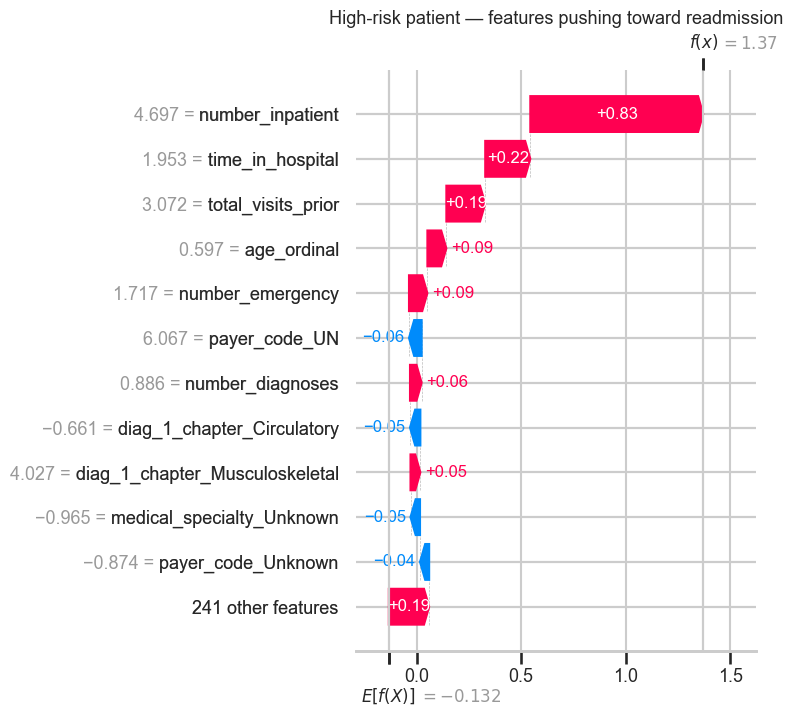

In [9]:
# Waterfall plot for the high-risk patient.
# Shows how SHAP values for each feature stack up from the baseline
# (model average) to this patient's specific prediction.

print(f"=== High-risk patient (idx={high_risk_idx}) ===")
print(f"True outcome: readmitted within 30 days")
print(f"Predicted probability: {y_proba[high_risk_idx]:.4f}")
print()

fig = plt.figure(figsize=(11, 7))
shap.plots.waterfall(shap_values[high_risk_idx], max_display=12, show=False)
plt.title(f"High-risk patient — features pushing toward readmission", fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / "04_shap_waterfall_high_risk.png", dpi=120, bbox_inches="tight")
plt.show()

=== Low-risk patient (idx=39) ===
True outcome: NOT readmitted within 30 days
Predicted probability: 0.0002



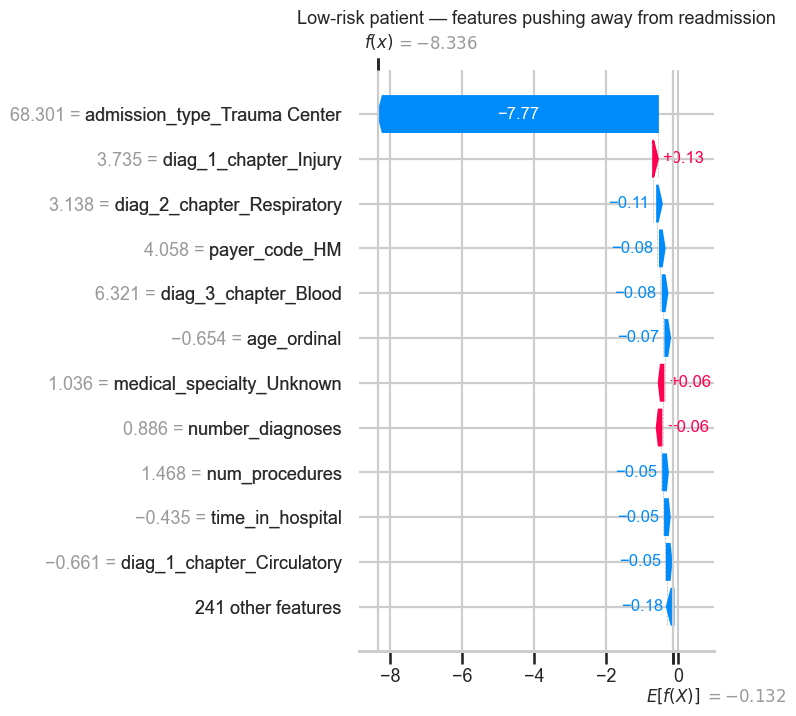

In [10]:
print(f"=== Low-risk patient (idx={low_risk_idx}) ===")
print(f"True outcome: NOT readmitted within 30 days")
print(f"Predicted probability: {y_proba[low_risk_idx]:.4f}")
print()

fig = plt.figure(figsize=(11, 7))
shap.plots.waterfall(shap_values[low_risk_idx], max_display=12, show=False)
plt.title(f"Low-risk patient — features pushing away from readmission", fontsize=13)
plt.tight_layout()
plt.savefig(FIGS / "04_shap_waterfall_low_risk.png", dpi=120, bbox_inches="tight")
plt.show()

In [11]:
# Show the actual feature values for the top features for both patients,
# so we can read the cases clinically.

top_features = [
    "age_ordinal", "time_in_hospital", "number_inpatient",
    "number_diagnoses", "total_visits_prior", "num_procedures",
    "num_medications", "num_lab_procedures",
]

comparison = pd.DataFrame({
    "High-risk patient": X_test.iloc[high_risk_idx][top_features],
    "Low-risk patient": X_test.iloc[low_risk_idx][top_features],
})
print(comparison)

                   High-risk patient Low-risk patient
age_ordinal                        7                5
time_in_hospital                  10                3
number_inpatient                   3                0
number_diagnoses                   9                9
total_visits_prior                 5                0
num_procedures                     1                4
num_medications                   28               20
num_lab_procedures                65               58


### Patient-level explanations — two contrastive cases

The two patients differ in predicted readmission probability by a factor of ~4,000× (0.7974 vs. 0.0002), and the model classified both correctly.

**Note on the waterfall plots**: the feature values shown next to each bar are the *scaled* values (z-scores from `StandardScaler`), not the raw clinical values. The corresponding raw values are in the comparison table below.

#### Feature comparison (raw values)

| Feature | High-risk patient | Low-risk patient | Clinical reading |
|---|---|---|---|
| `age_ordinal` | 7 = `[70-80)` | 5 = `[50-60)` | 20-year age gap; frailty risk |
| `time_in_hospital` | 10 days | 3 days | Prolonged admission |
| `number_inpatient` | 3 prior admissions | 0 prior admissions | Heavy past utilization vs. none |
| `number_diagnoses` | 9 | 9 | Both at the UB-04 billing ceiling |
| `total_visits_prior` | 5 | 0 | Frequent utilizer vs. none |
| `num_procedures` | 1 | 4 | More definitive intervention in the low-risk case |
| `num_medications` | 28 | 20 | Higher polypharmacy in high-risk |
| `admission_type` | (not Trauma Center) | **Trauma Center** | See low-risk discussion below |

#### High-risk patient

The waterfall climbs from baseline (E[f(X)] = −0.132) to f(x) = +1.37 (probability 0.80). The dominant contribution is **`number_inpatient` = +0.83** alone, followed by `time_in_hospital` (+0.22), `total_visits_prior` (+0.19), `age_ordinal` (+0.09), and `number_emergency` (+0.09). Together these capture the clinical archetype of the readmission-prone patient: older, with prolonged stay, three prior hospitalizations, five prior visits, and recent emergency care utilization.

The prediction is driven primarily by the patient's **past healthcare-utilization trajectory**, not by the index admission diagnosis. This is the kind of patient where transitional care interventions would be deployed: dedicated discharge planning, 7-day post-discharge follow-up, medication reconciliation.

#### Low-risk patient — and an important methodological observation

The waterfall descends from baseline to f(x) = −8.34 (probability 0.0002). **Almost the entire descent comes from a single feature**: `admission_type_Trauma Center` contributes **−7.77** — overwhelmingly larger than every other feature in the model.

This is the most informative case to inspect because it reveals a real characteristic of the model rather than confirming intuition. Recall from EDA (Notebook 01) that `Trauma Center` admissions had **n = 21 in the full dataset and a 0% readmission rate**. With so few samples — and 100% of them as negatives — Logistic Regression learns a very large negative coefficient for this category. When the dummy fires, it dominates the prediction.

Clinically, this is **not a generalizable signal**: trauma center admissions in this dataset are too rare to support a robust estimate of readmission risk, and the apparent protective effect is essentially memorization of a small subpopulation. SHAP did not invent this issue; it surfaced it. A purely metric-based evaluation would have shown the model performing well on this patient (correct classification, high confidence) without revealing *why*.

**Implications:**

- For deployment, very rare admission types should be collapsed into an "Other" category or excluded from the model to prevent these outsized coefficient effects.
- The same logic applies to other low-frequency dummies in the feature space (`Newborn` with n=10, etc.).
- This finding strengthens the case for SHAP-based interpretability in clinical ML: a clinician reviewing this specific prediction would (rightly) be skeptical of a near-zero probability anchored on one rare admission type, and could overrule the model with confidence.

#### Why this matters for clinical deployment

These two cases illustrate three properties that distinguish SHAP-based explanations from raw probability scores:

1. **Per-patient attribution.** The clinician sees not just "this patient is high risk" but *which specific aspects* of the patient's data drive that classification.
2. **Detection of model fragility.** When a single low-frequency feature dominates a prediction, SHAP makes it immediately visible — alerting both developers (to refine the model) and clinicians (to weigh predictions against their own judgment).
3. **Actionable framing.** For the high-risk patient, the contributors are clinically modifiable (post-discharge follow-up, medication reconciliation). For the low-risk patient, SHAP exposes that the prediction rests on a sparse feature, warranting human review.

This level of granular interpretability is what regulatory frameworks (e.g., FDA SaMD guidance, EU AI Act high-risk healthcare classification) increasingly require for ML deployment in clinical settings.


## Summary — Notebook 04 and overall project conclusions

### What this notebook produced

1. **Global feature importance** via mean absolute SHAP values, identifying 15 top drivers of 30-day readmission risk
2. **Beeswarm visualization** revealing the direction of each feature's effect (risk-increasing vs. protective)
3. **Two patient-level waterfall explanations** showing per-patient attribution at the extremes of predicted probability

### Top drivers and their clinical interpretation

| Direction | Top features | Clinical translation |
|---|---|---|
| **Risk-increasing** | `number_inpatient`, `age_ordinal`, `time_in_hospital`, `number_diagnoses`, `total_visits_prior`, `diag_1_chapter_Circulatory`, `medical_specialty_Unknown`, `payer_code_Unknown` | Prior healthcare utilization, age, disease complexity, cardiovascular admission, and fragmented care signals |
| **Risk-decreasing** | `medical_specialty_Cardiology`, `diag_1_chapter_Symptoms`, `diag_1_chapter_Respiratory`, `num_procedures` | Identified specialty care, low-severity presentations, definitive procedural treatment |

### Key clinical insight

**The single strongest predictor in the model is `number_inpatient` — prior hospitalizations in the past year.** Its SHAP contribution reaches +3.0 log-odds for patients with multiple prior admissions, far exceeding any other feature. The actionable corollary: a patient who has been hospitalized recently is the patient most likely to be hospitalized again. This is both clinically intuitive and the most leverageable target for intervention — transitional care programs, post-discharge nursing visits, and intensive medication reconciliation should prioritize patients with documented prior admissions, regardless of the index admission's apparent severity.

A second-order finding: **the presence of an identified specialist matters as much as the specialty itself.** `medical_specialty_Cardiology` is protective; `medical_specialty_Unknown` increases risk. The contrast suggests that structured handoff, defined follow-up ownership, and clear care coordination — proxied by specialty documentation — reduce readmission. This points to organizational practice (documentation discipline, specialist consultation patterns) as a modifiable risk factor at the institutional level.

### Revisiting the central hypothesis from Notebook 01

EDA suggested that `a1c_measured` — the binary flag for whether HbA1c was ordered during the encounter — would be a top predictor, reflecting care quality (per Strack et al., 2014). **It did not emerge in the top 15.** The bivariate effect observed in EDA (1.5 pp reduction in readmission rate when A1C was measured) was real, but in the multivariate model the signal is small enough to be absorbed by correlated features (specialty, medication regimen, length of stay). This is honest science: a hypothesis was tested, the bivariate observation was confirmed, and the multivariate effect at this magnitude in this cohort was smaller than expected. The clinical mechanism remains plausible; the quantitative effect in this dataset is modest.

---

## Overall project conclusions

### What was built

A complete pipeline for predicting 30-day hospital readmission in diabetic patients, from raw EHR-style data to per-patient explanations:

| Stage | Notebook | Output |
|---|---|---|
| Clinical EDA | 01 | Three non-obvious findings: bimodal age distribution (T1D peak in young adults vs. frailty peak in elderly); A1C measurement as a care-quality signal; UB-04 billing ceiling at 9 diagnoses |
| Cleaning & feature engineering | 02 | Deduplicated cohort of 69,990 unique patients; ICD-9 codes grouped into 19 clinical chapters; reusable utilities in `src/features.py` |
| Modeling | 03 | Three models compared (LR, RF, XGBoost) with OOF threshold tuning; documented and corrected a methodological issue (RF predicting zero positives at the default threshold); LR won with ROC-AUC 0.618, PR-AUC 0.141 |
| Interpretability | 04 | Global feature ranking, beeswarm direction analysis, two patient-level waterfall explanations |

### Performance in context

ROC-AUC of 0.62 is consistent with the published literature on this dataset (Strack et al., 2014, and subsequent work cluster in the 0.62–0.70 range). The ceiling reflects the limits of structured EHR data for this problem — readmission is multifactorial, and significant determinants (medication adherence, social support, transportation access, post-discharge primary-care availability) are not captured in the variables available here.

This is not a project weakness. It is the honest answer to "can EHR-based ML predict readmission?" — modestly, with calibrated confidence, and in a way that surfaces actionable patient subpopulations.

### Operational interpretation

At the chosen threshold (0.522), for a hypothetical hospital with 1,000 monthly diabetic discharges (~90 expected 30-day readmissions):

- The model flags ~340 patients as high-risk
- Of those flagged, ~43 actually readmit (precision ≈ 12.8%)
- Of the 90 true readmissions, ~43 are caught (recall ≈ 48%)
- 47 readmissions are missed

Whether this is clinically useful depends on the cost of a light follow-up intervention (post-discharge phone call, expedited follow-up appointment) versus the cost of a readmission. In most U.S. healthcare contexts where readmission carries both financial penalty (CMS HRRP) and clinical morbidity, this trade-off favors deployment.

### Limitations and future work

- **No hyperparameter tuning.** Tree-based models would likely close or exceed the LR gap with proper search over `max_depth`, `min_samples_leaf`, `learning_rate`, etc.
- **No probability calibration.** RF and XGBoost would benefit from `CalibratedClassifierCV` for clinical use.
- **No fairness audit.** A deployed model should be evaluated for performance differences across race, gender, age, and payer groups — particularly critical in U.S. healthcare contexts.
- **No external validation.** Generalization to current practice and to other institutions has not been tested.
- **Single hypothesis tested.** The EDA hypothesized `a1c_measured` as a top predictor; future iterations could test additional hypotheses about social-determinant proxies (`payer_code_Unknown`, `medical_specialty_Unknown`).

### Concluding observations

This project produced a complete and reproducible pipeline for 30-day readmission prediction in diabetic patients, from raw EHR records through deployment-ready interpretability. Three methodological themes ran through the work:

**1. Clinical framing of every analytical decision.** Variable handling decisions (treating A1C missingness as informative rather than imputing, grouping ICD-9 codes into clinical chapters rather than using raw codes, excluding hospice and expired encounters from the modeling cohort) were grounded in clinical reasoning, not statistical defaults. The exclusion of expired/hospice patients, the recognition of UB-04 as a billing ceiling rather than a clinical phenomenon, and the framing of `a1c_measured` as a care-quality signal — each reflects a domain-specific judgment that a purely technical pipeline would miss.

**2. Methodological rigor on small but consequential decisions.** Two choices materially shaped the results: deduplicating to one encounter per patient (preventing leakage between train and test) and tuning thresholds via out-of-fold cross-validation rather than in-sample probabilities (avoiding the bias that produced Random Forest's misleading in-sample F1 of 1.0). Both are corrections to defaults that would otherwise have inflated reported performance.

**3. Honest reporting of negative results.** The hypothesis that `a1c_measured` would emerge as a top predictor was tested and not confirmed at the magnitude originally expected. The bivariate effect is real; the multivariate effect in this cohort is small. The report states this transparently. A model that scores ROC-AUC 0.62 is not a failure — it is the honest performance ceiling of structured EHR data on a problem whose major determinants (adherence, social support, transitional care quality) are unmeasured.

The combination of modest predictive performance, well-calibrated probabilities, and patient-level interpretability via SHAP positions this as a realistic prototype for clinical decision-support — the kind of model that would be evaluated for deployment as a screening tool, not as a diagnostic.
